# Interfacing the world to a computer

Your Name:  <span style="background-color:yellow">Cole Stevens</span>
</span>

### Learning Outcomes

* Interface a LabJack U3 to the computer
* Design and build a circuit to produce a voltage output from a thermistor
* Condition a voltage signal for input to the LabJack interface
* Write commands to take voltage data as a function of time from the LabJack
* Obtain temperature vs. time data for a thermistor in different liquid baths

## Measuring temperature as a function of time

**GOAL**: Obtain temperature as a function of time over the range 0-100 $^\circ$ C using a thermistor and LabJack.

You could get a thermometer and write down numbers every so often.  If you wanted to take data over a long period of time (hours, days) or you wanted to get data quickly (every 1 second) that might not be reasonable with pencil and paper. But we now know how to use the computer for this type of measurement.

To interrogate the natural world and get a signal into our computer we need to 

* get a signal from the world using a transducer, 
* condition (reduce, amplify, filter, etc.) the signal appropriate for an interface,
* connect to an interface, and
* connect the interface to a computer.

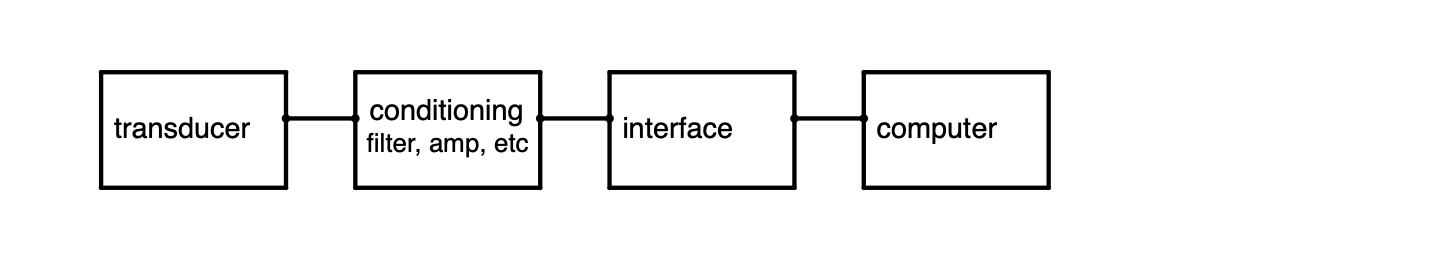

Figure: Getting data from the world to a computer.

Let's follow the steps outlined above. A **transducer** is a device that changes some physical property in response to changes in another physical property.  For example, the resistance of a *thermistor* changes if the temperature of the thermistor changes.

Many common computer interfaces expect a voltage signal.  This is true even if the quantity of interest is temperature or pressure or... So the physical transducer property needs to be turned into a voltage which, as is, might not be appropriate for an interface.  That voltage may need to be *conditioned* (amplified, filtered, etc.) before being put into the interface.  The interface is then connected to and controlled by the computer.

### LabJack U3 interface (analog input)

In this lab, we will be using a LabJack U3 interface (there is one in your drawer) for reading voltages and getting them into your computer.  It has analog signal inputs (AIN0, AIN1,...) that accept signals in the range $\pm 10\ \text{V}$ relative to ground (GND).  These, and similar devices, perform well and are inexpensive (hundreds of dollars) compared to the benchtop instruments you have in front of you (thousands of dollars).

### Using the LabJack

We can use the computer to talk to the LabJack interface so we can take data.  The procedure and commands are very similar to what you have been doing with `pyvisa` and the benchtop instruments (DMM, power supply, waveform generator, scope), but the specifics are different.  

It is a different physical device (LabJack U3), from a different company 
([LabJack](http://www.labjack.com)) so the Python library is different (`u3`). 
The relevant hardware drivers and corresponding Python library have been installed on the lab computers.

The general plan is, however, the same: 

* `import` the Python library `u3`, 
* define a device and connect to the interface,
* send commands to the device (get data, set voltage, etc.).

### Testing the LabJack

Connect the LabJack U3 to your computer with the USB cord (use the USB port on the computer itself, not on the monitor or keyboard).  To get started, connect the output of your power supply (set at a **voltage < 4.0 V**) to the *A*nalog *In*put *0* terminals on the LabJack, labelled "AIN0" (high potential) and "GND" (low potential). Now let's read this voltage with the computer.  

**Troubleshooting tip**: Even though you are using the LabJack to interface with the computer, is there a way you can check your signals as you go with another piece of equipment?

**Connection notes**: Be sure to put your wires into the relevant screw terminals (see Figure) and then tighten down the internal clamp using a screwdriver.  Look into the terminal and you will see two metal "plates" one of which can move.  Place the wire between them and, with a screwdriver, tighten down from the top.

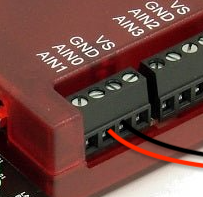

Figure: LabJack U3 screw terminals showing wire location.

The command for finding and defining a device is `yourlabel = u3.U3()`.  You choose `yourlabel`, in this example we use `d` for device. The `u3` with lowercase `u` is the library, the `U3` with uppercase `U` is the physical device.  The protocol will connect to the first U3 device it finds.  In general, you could have more than one, but we will only use one at a time.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import u3   # Python library, LabJack model "U3"

In [5]:
labjack = u3.U3()  # create device
print(labjack.configU3())  # show "labjack" information

{'FirmwareVersion': '1.44', 'BootloaderVersion': '0.27', 'HardwareVersion': '1.30', 'SerialNumber': 320055842, 'ProductID': 3, 'LocalID': 1, 'TimerCounterMask': 64, 'FIOAnalog': 15, 'FIODirection': 0, 'FIOState': 0, 'EIOAnalog': 0, 'EIODirection': 0, 'EIOState': 0, 'CIODirection': 0, 'CIOState': 0, 'DAC1Enable': 1, 'DAC0': 0, 'DAC1': 0, 'TimerClockConfig': 2, 'TimerClockDivisor': 256, 'CompatibilityOptions': 0, 'VersionInfo': 18, 'DeviceName': 'U3-HV'}


You should see information regarding your U3 device including Firmware, Serial Number, etc.

Now that we can communicate with the interface, let's read the voltage on the input Analog Input Channel 0 (AIN0).

In [3]:
voltage = labjack.getAIN(0) # Read from AIN0
print(voltage)

1.993727999999999


The voltage read from the LabJack should be (pretty) close to the voltage that you set on your power supply.

Let's test this new interface device in a program.

**EXERCISE 1**: Write and run a program that will take voltage data at specific time intervals as you **manually** change your power supply voltage from $0\;V$ to $4\;V$.  Use a `while` loop.

* Python has a time library which can be accessed via `import time`.
* Collect some data (20 data points?) getting a voltage reading every so often (2 seconds?). While collecting data you can pause your program for a specific amount of time by invoking the command `time.sleep(time in seconds)`.
* You will need to create a time variable to keep track of the time. Use the command `t = time.time()` which will return the number of seconds since 1970 in the variable `t`. (It's easiest to test the program by varying the voltage in a specific known pattern. For example, 1 V for 2 seconds, 2 V for 2 seconds, etc. or similar.)
* Plot the voltage (vertical) vs. time (horizontal) with labels, origin, etc.


In [2]:
# student commands here
import time
import pyvisa

In [3]:
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL2::INSTR',
 'ASRL10::INSTR',
 'GPIB0::10::INSTR',
 'GPIB0::22::INSTR',
 'GPIB0::5::INSTR',
 'USB0::0x0957::0x179B::MY52166481::0::INSTR')

In [33]:
ps = rm.open_resource('GPIB0::5::INSTR')
print(ps.query("*IDN?"))

Agilent Technologies,E3646A,0,1.7-5.0-1.0



In [15]:
type(readvolt)

str

In [17]:
t_rec = []
volt = []
t = time.time()
T = time.time() + 60
while t < T:
    t_rec.append(t)
    readvolt = ps.query("MEAS:VOLT:DC?", 1)
    readvolt = np.round(float(readvolt), 3)
    volt.append(readvolt)
    time.sleep(2)
    t = time.time()
print(t_rec)
print(volt)

[1771626279.4404104, 1771626282.450864, 1771626285.4551036, 1771626288.4678988, 1771626291.4717126, 1771626294.475585, 1771626297.479615, 1771626300.4838567, 1771626303.487788, 1771626306.4916892, 1771626309.4953377, 1771626312.4992785, 1771626315.5036297, 1771626318.509305, 1771626321.5155034, 1771626324.522358, 1771626327.5284748, 1771626330.5350177, 1771626333.542169, 1771626336.5494006]
[np.float64(1.0), np.float64(1.0), np.float64(3.003), np.float64(2.002), np.float64(4.003), np.float64(3.003), np.float64(2.002), np.float64(1.0), np.float64(-0.001), np.float64(2.002), np.float64(3.003), np.float64(4.003), np.float64(4.004), np.float64(3.003), np.float64(1.0), np.float64(2.002), np.float64(3.003), np.float64(3.003), np.float64(2.002), np.float64(4.003)]


In [ ]:
#convert the time data to be between 0 and 100

In [ ]:
null = t_rec[0]

Text(0, 0.5, 'Voltage (V)')

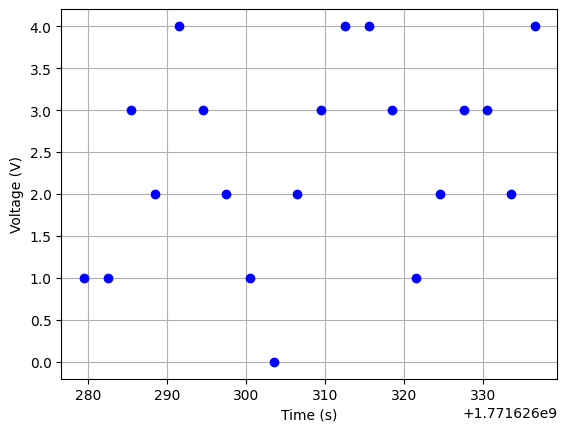

In [19]:
plt.plot(t_rec, volt, 'bo')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.ylim(0,4.5)

**Do not connect your circuits to the LabJack until Exercise 4.**

## Thermistor circuit

In some cases a transducer will directly produce a voltage. We have thermistors (LM 102) so will need a circuit that produces a voltage from which we can find the resistance, and then using the fitted function from your At Home Activity you can determine the temperature.  Assume that for a variety of cost, packaging, and assembly reasons you are given a a thermistor (LM 102) and a 1.5 V battery.  

**EXERCISE 2**: Design and build a circuit using a thermistor (essentially a variable resistor) and a 1.5 V battery to produce a voltage output. (It will go into the LabJack U3 after conditioning.) 

To get a sense of appropriate component values take a look at the resistance and temperature calibration chart.

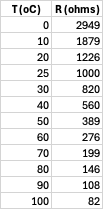

* There are a variety of possible circuits.  As you consider one, you might try it on Falstad.
* Once you have identified a circuit that will work, build it and test it.  (What are you looking for when you test it?)
* Leave it on your breadboard for the next portion of the lab. 

<span style="background-color:yellow">Include a schematic of your thermistor circuit here, and any testing code/plots/data below.</span>

#Thermistor Circuit Schematic
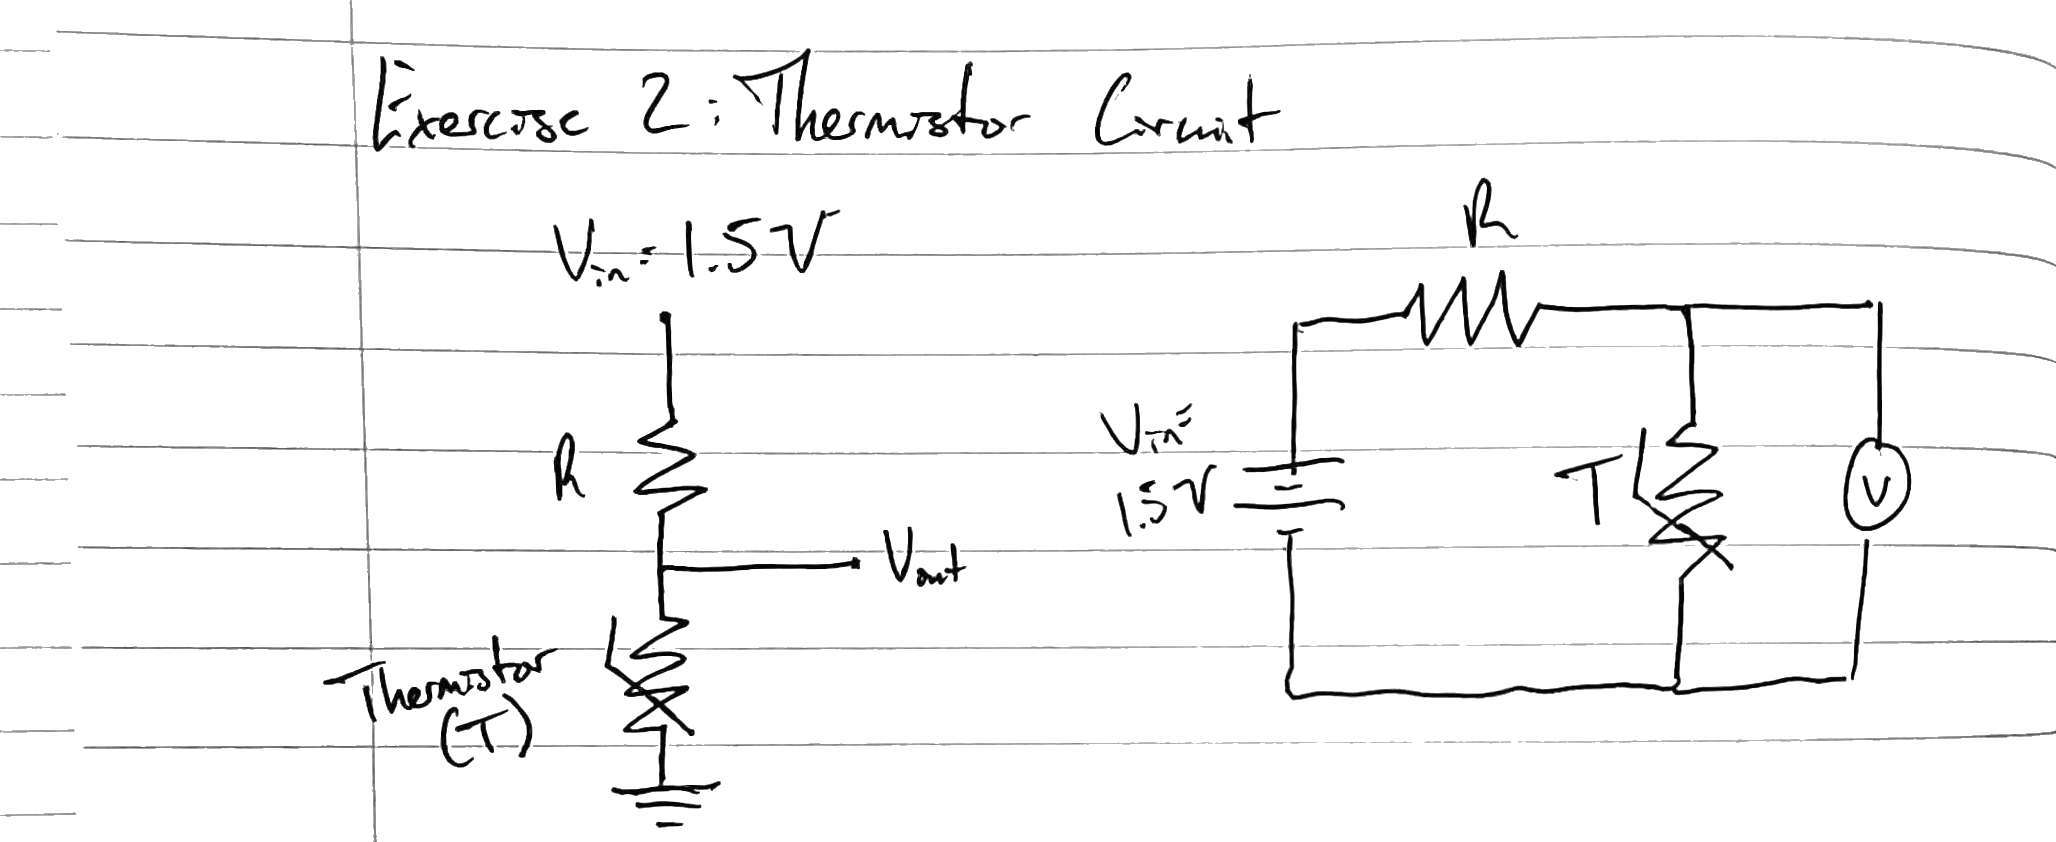

In [1]:
R = 991 Ohm
T = ?
Vin = 1.614 V
Vout = 0.861 V
V_R = 0.861 V
I_R = V_R / R = 0.76 mA
T = Vout / I_R = 1133 Ohm
T should be close to 1200 Ohm
T ~ 1200 Ohm
#This means we good!

SyntaxError: invalid syntax (1534785780.py, line 1)

## Conditioning circuit

Now you have a circuit that gives voltages with a maximum of 1.5 V. This voltage needs to be put into the LabJack U3. The LabJack gives optimum results with signals that span as much of the 0 to 10 V range as possible.  This takes advantage of the full dynamic range and available resolution.

**EXERCISE 3**: Design and build a circuit which takes the ouput of your thermistor circuit and conditions it for input to the LabJack (0-10 V).  Remember that the 741 op-amp will not output more than 25 mA.  Build and test your circuit. 

<span style="background-color:yellow">Include a schematic of your conditioned thermistor circuit here, and any testing code/plots/data below.</span>

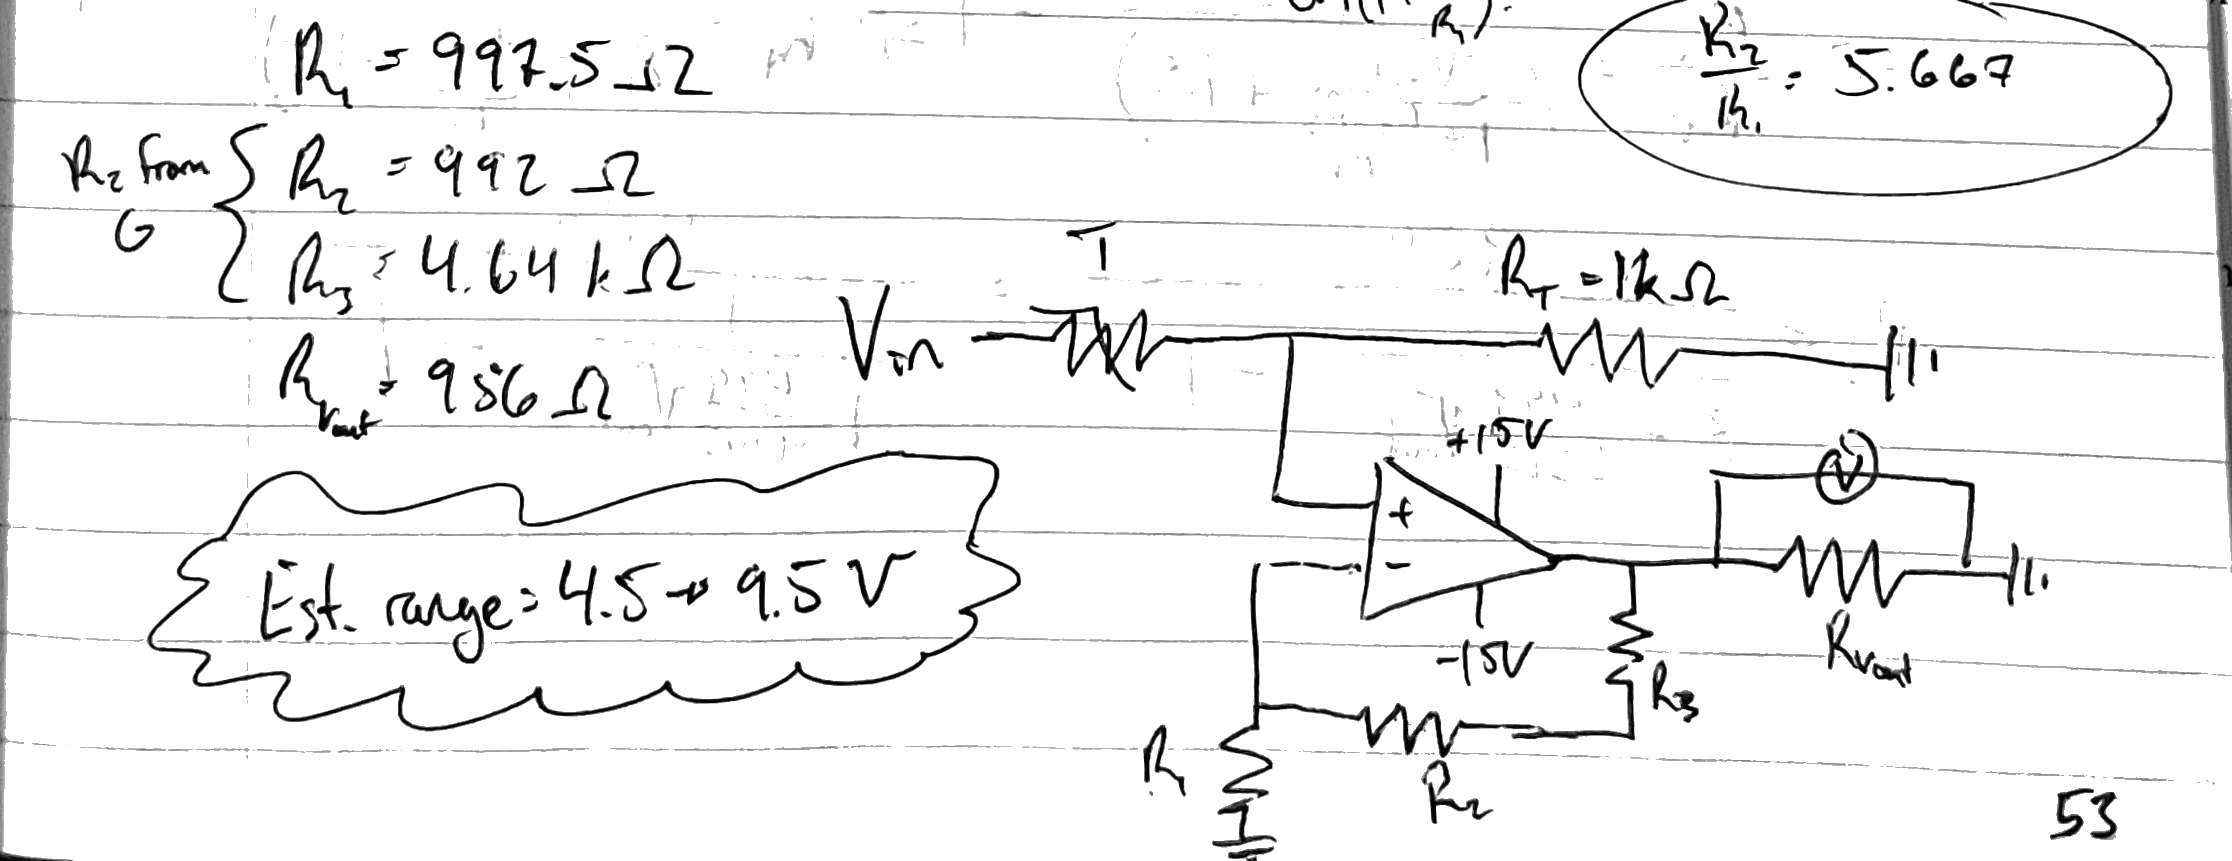

In [7]:
import time
import numpy as np
dmm = rm.open_resource('GPIB0::22::INSTR')
print(dmm.query("*IDN?"))

HEWLETT-PACKARD,34401A,0,11-5-2



In [29]:
t_meas = []
v = []
t = time.time()
T = time.time() + 30
while t < T:
    t_meas.append(t)
    readvolt = dmm.query("MEAS:VOLT:DC?", 1)
    readvolt = np.round(float(readvolt), 3)
    v.append(readvolt)
    time.sleep(0.1)
    t = time.time()
print(t_meas)
print(v)

[1772059607.5807364, 1772059608.6929166, 1772059609.7987854, 1772059610.9056587, 1772059612.011741, 1772059613.1174905, 1772059614.2233043, 1772059615.3300452, 1772059616.4370544, 1772059617.5441036, 1772059618.6505287, 1772059619.7575908, 1772059620.8639615, 1772059621.969667, 1772059623.0851707, 1772059624.1908906, 1772059625.2969398, 1772059626.4025016, 1772059627.5087028, 1772059628.624002, 1772059629.7312481, 1772059630.8383093, 1772059631.943815, 1772059633.0495348, 1772059634.1543887, 1772059635.260924, 1772059636.3672147, 1772059637.4739146]
[np.float64(4.413), np.float64(4.411), np.float64(5.312), np.float64(7.879), np.float64(8.389), np.float64(8.535), np.float64(8.613), np.float64(8.672), np.float64(8.727), np.float64(8.762), np.float64(8.77), np.float64(8.77), np.float64(8.771), np.float64(8.772), np.float64(8.769), np.float64(8.756), np.float64(7.825), np.float64(6.168), np.float64(5.5), np.float64(5.164), np.float64(4.969), np.float64(4.846), np.float64(4.764), np.float64

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
df = []
df = pd.DataFrame(v)
df.to_csv('lab6_v_5.6k_25Feb2026.csv', index = False)
df = []
df = pd.DataFrame(t_meas)
df.to_csv('lab6_t_meas_5.6k_25Feb2026.csv', index = False)

In [28]:
df = []
df = pd.DataFrame(v)
df.to_csv('lab6_v_6.8k_25Feb2026.csv', index = False)
df = []
df = pd.DataFrame(t_meas)
df.to_csv('lab6_t_meas_6.8k_25Feb2026.csv', index = False)

(4.0, 9.0)

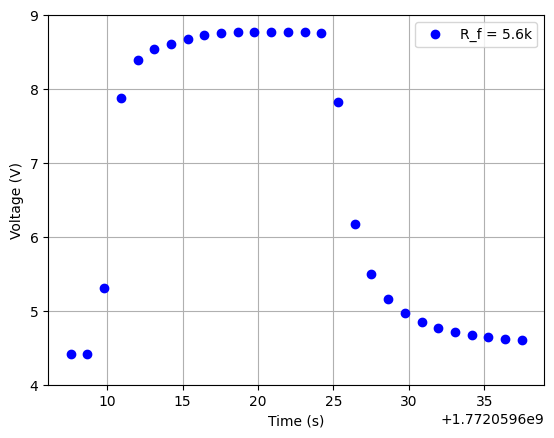

In [32]:
plt.plot(t_meas, v, 'bo', label = 'R_f = 5.6k')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.ylim(4,9)

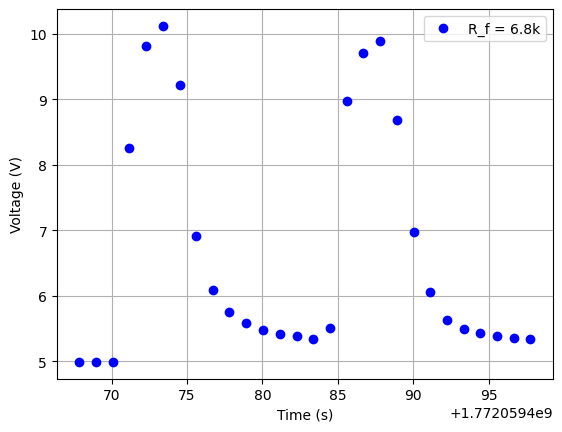

In [27]:
plt.plot(t_meas, v, 'bo', label = 'R_f = 6.8k')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()

## Connecting to the LabJack

At this stage you have two connected circuits (thermistor and conditioning) which combine to produce voltages between 0 and 10 V that we want to get into the computer.  Connect the output of this to your LabJack so that you can take data.

**EXERCISE 4**: Write a program to get voltage signals from your connected circuit via the LabJack.  For now, just take data at room temperature and raise the temperature slightly by holding the thermistor between your fingers.  Then let go and allow the thermistor to cool.  Plot your data.  Show a schematic of your overall circuit.


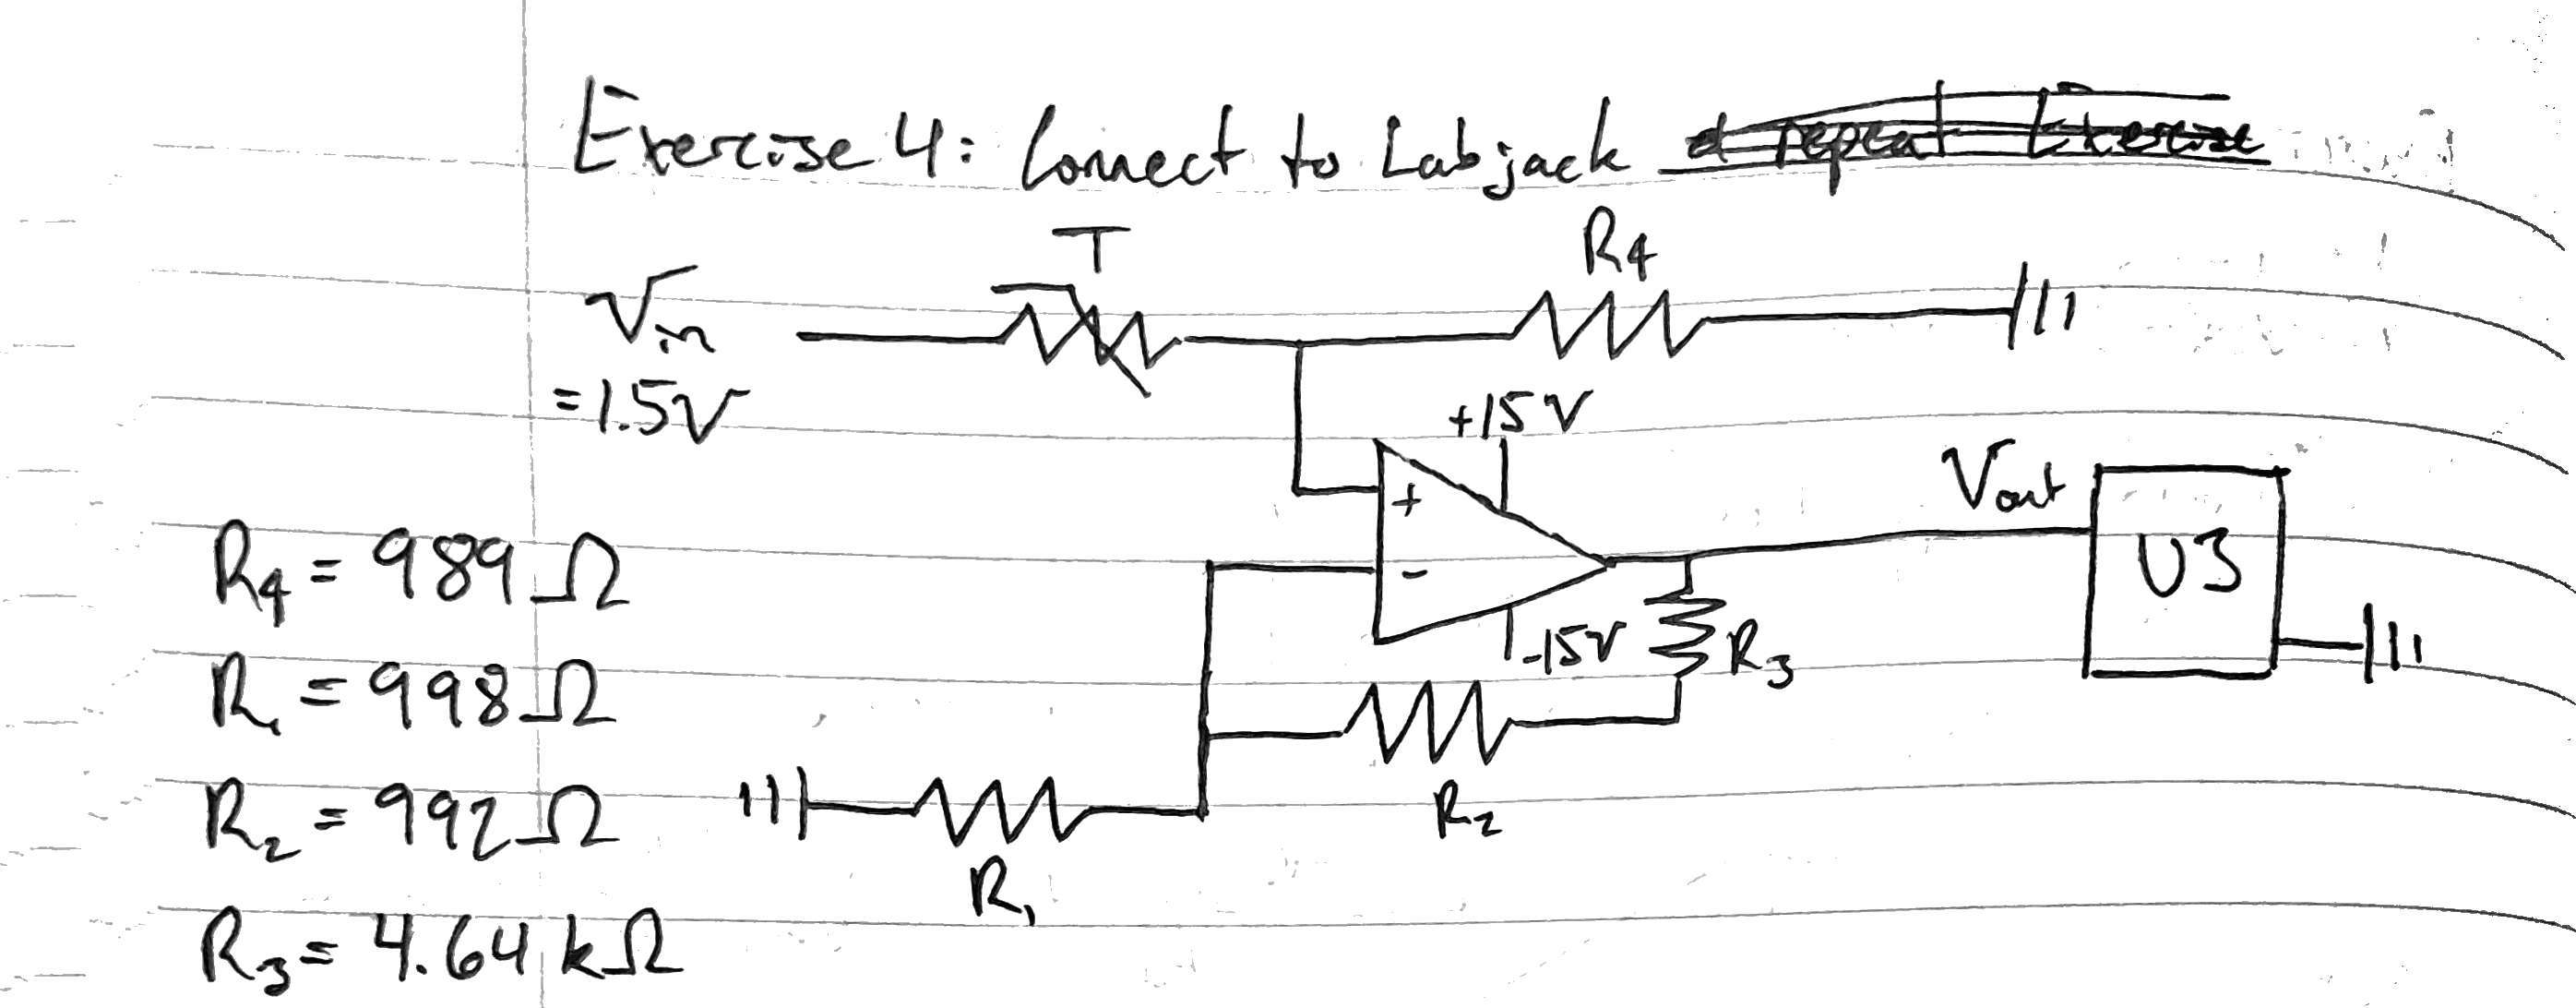

In [1]:
# student code goes here
import u3 
labjack = u3.U3()
print(labjack.configU3())

{'FirmwareVersion': '1.44', 'BootloaderVersion': '0.27', 'HardwareVersion': '1.30', 'SerialNumber': 320055842, 'ProductID': 3, 'LocalID': 1, 'TimerCounterMask': 64, 'FIOAnalog': 15, 'FIODirection': 0, 'FIOState': 0, 'EIOAnalog': 0, 'EIODirection': 0, 'EIOState': 0, 'CIODirection': 0, 'CIOState': 0, 'DAC1Enable': 1, 'DAC0': 0, 'DAC1': 0, 'TimerClockConfig': 2, 'TimerClockDivisor': 256, 'CompatibilityOptions': 0, 'VersionInfo': 18, 'DeviceName': 'U3-HV'}


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import time
import numpy as np

In [28]:
voltage = labjack.getAIN(0)
print(voltage)

4.44544


In [30]:
t_m = []
jack_volt = []
t = time.time()
T = time.time() + 30
while t < T:
    t_m.append(t)
    voltage = labjack.getAIN(0)
    jack_volt.append(voltage)
    time.sleep(0.1)
    t = time.time()
print(t_m)
print(jack_volt)

[1772138083.4756927, 1772138083.5768883, 1772138083.6780305, 1772138083.780107, 1772138083.88228, 1772138083.9849577, 1772138084.0869622, 1772138084.1892605, 1772138084.2912064, 1772138084.3928416, 1772138084.4946506, 1772138084.596346, 1772138084.6982188, 1772138084.8005314, 1772138084.902661, 1772138085.0047963, 1772138085.1065736, 1772138085.2082145, 1772138085.3102615, 1772138085.4122849, 1772138085.5137966, 1772138085.6155086, 1772138085.717827, 1772138085.8197832, 1772138085.922084, 1772138086.0243764, 1772138086.1260848, 1772138086.2280812, 1772138086.3299823, 1772138086.4318752, 1772138086.5340676, 1772138086.636264, 1772138086.738257, 1772138086.840245, 1772138086.942372, 1772138087.044454, 1772138087.1462147, 1772138087.2487578, 1772138087.3507695, 1772138087.4523075, 1772138087.5541575, 1772138087.6563122, 1772138087.7587097, 1772138087.8603745, 1772138087.9623291, 1772138088.064299, 1772138088.1663287, 1772138088.2688158, 1772138088.3709297, 1772138088.4728942, 1772138088.5

In [56]:
df = []
df = pd.DataFrame(jack_volt)
df.to_csv('lab6_jack_volt_26Feb2026.csv', index = False)
df = []
df = pd.DataFrame(t_m)
df.to_csv('lab6_t_m_labjack_26Feb2026.csv', index = False)

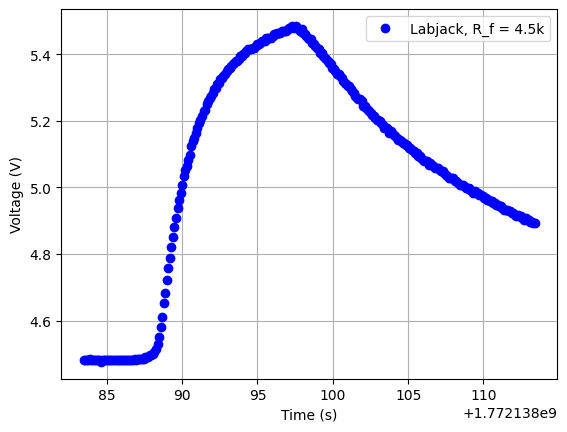

In [32]:
plt.plot(t_m, jack_volt, 'bo', label = 'Labjack, R_f = 4.5k')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()

## Putting it all together: Temperature vs. time

You should now have circuits, an interface and a connection to the computer.  Along with your fitting function for the thermistor you should be able to determine the temperature.

**EXERCISE 5**: As needed, modify your previous program to obtain voltage data every 1 second from the thermistor when immersed in (a) a warm bath and then removed and (b) (separately) a cold bath and then removed.  Take data for long enough to allow your thermistor to equilibrate and get a good estimate of the temperature at each stage (before immersion, during immersion, after immersion), and to observe some of the return to room temperature.  Be sure to **save your data**, as you may be asked to estimate cooling/warming rates in the PostLab.

* Obtain voltage data as you put the thermistor into/out of different baths.
* Knowing the properties of your conditioning circuit use the measured voltage to determine thermistor resistance as a function of $v_{\text{out}}$.
* Using resistance (from voltage) and your fitting function $T(R)$, determine the temperature of the thermistor. (Include any calculations.)
* Plot the temperature (vertical) vs. time (horizonal) with labels, origin, etc.


In [2]:
# student code goes here
import matplotlib.pyplot as plt
import pandas as pd
import time
import numpy as np
import u3

ModuleNotFoundError: No module named 'u3'

In [3]:
labjack = u3.U3()
print(labjack.configU3())

{'FirmwareVersion': '1.44', 'BootloaderVersion': '0.27', 'HardwareVersion': '1.30', 'SerialNumber': 320055842, 'ProductID': 3, 'LocalID': 1, 'TimerCounterMask': 64, 'FIOAnalog': 15, 'FIODirection': 0, 'FIOState': 0, 'EIOAnalog': 0, 'EIODirection': 0, 'EIOState': 0, 'CIODirection': 0, 'CIOState': 0, 'DAC1Enable': 1, 'DAC0': 0, 'DAC1': 0, 'TimerClockConfig': 2, 'TimerClockDivisor': 256, 'CompatibilityOptions': 0, 'VersionInfo': 18, 'DeviceName': 'U3-HV'}


Part A

In [13]:
Time_h = []
jack_v_h = []
t = time.time()
T = time.time() + 70
while t < T:
    Time_h.append(t)
    voltage = labjack.getAIN(0)
    jack_v_h.append(voltage)
    time.sleep(1)
    t = time.time()
print(Time_h)
print(jack_v_h)

[1772144810.5928626, 1772144811.5949209, 1772144812.596543, 1772144813.5978384, 1772144814.5989437, 1772144815.6006477, 1772144816.6024215, 1772144817.6040547, 1772144818.6064444, 1772144819.6078901, 1772144820.6099532, 1772144821.6116934, 1772144822.6134162, 1772144823.6153278, 1772144824.6173213, 1772144825.6187022, 1772144826.619785, 1772144827.6219254, 1772144828.623955, 1772144829.6253295, 1772144830.6262553, 1772144831.6278052, 1772144832.6291485, 1772144833.6305907, 1772144834.6321418, 1772144835.6338334, 1772144836.635243, 1772144837.6369638, 1772144838.6384685, 1772144839.639879, 1772144840.641964, 1772144841.6437619, 1772144842.645466, 1772144843.6469917, 1772144844.6486685, 1772144845.6495912, 1772144846.651202, 1772144847.653373, 1772144848.6553364, 1772144849.6576948, 1772144850.6592693, 1772144851.6608841, 1772144852.662482, 1772144853.6639528, 1772144854.6658401, 1772144855.667737, 1772144856.6695573, 1772144857.6715086, 1772144858.6728868, 1772144859.674954, 1772144860.

In [16]:
df = []
df = pd.DataFrame(jack_v_h)
df.to_csv('lab6_jack_v_h_26Feb2026.csv', index = False)
df = []
df = pd.DataFrame(Time_h)
df.to_csv('lab6_Time_h_labjack_26Feb2026.csv', index = False)

In [3]:
jack_v_h = pd.read_csv('lab6_jack_v_h_26Feb2026.csv')
Time_h = pd.read_csv('lab6_Time_h_labjack_26Feb2026.csv')

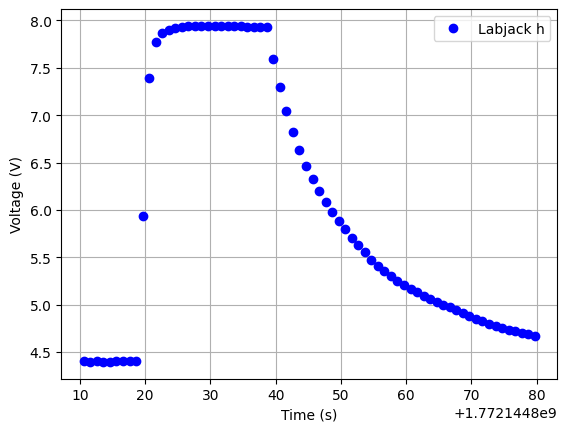

In [4]:
plt.plot(Time_h, jack_v_h, 'bo', label = 'Labjack h')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()

Part B

In [17]:
Time_c = []
jack_v_c = []
t = time.time()
T = time.time() + 70
while t < T:
    Time_c.append(t)
    voltage = labjack.getAIN(0)
    jack_v_c.append(voltage)
    time.sleep(1)
    t = time.time()
print(Time_c)
print(jack_v_c)

[1772145052.8218184, 1772145053.8233666, 1772145054.82537, 1772145055.8275082, 1772145056.8296556, 1772145057.8317883, 1772145058.8339643, 1772145059.8354676, 1772145060.837141, 1772145061.8387341, 1772145062.8401954, 1772145063.842157, 1772145064.844425, 1772145065.846535, 1772145066.8483312, 1772145067.8504183, 1772145068.851502, 1772145069.8530865, 1772145070.854969, 1772145071.8569229, 1772145072.8584828, 1772145073.8602507, 1772145074.8620079, 1772145075.8636293, 1772145076.865201, 1772145077.867076, 1772145078.8688846, 1772145079.8706815, 1772145080.872002, 1772145081.873861, 1772145082.8754961, 1772145083.8766935, 1772145084.8788962, 1772145085.880593, 1772145086.8820624, 1772145087.8842716, 1772145088.8864253, 1772145089.8880944, 1772145090.8898337, 1772145091.8915875, 1772145092.8931763, 1772145093.8946722, 1772145094.8959284, 1772145095.8971379, 1772145096.898352, 1772145097.9013736, 1772145098.9034493, 1772145099.9053774, 1772145100.9065795, 1772145101.9088202, 1772145102.91

In [18]:
df = []
df = pd.DataFrame(jack_v_c)
df.to_csv('lab6_jack_v_c_26Feb2026.csv', index = False)
df = []
df = pd.DataFrame(Time_c)
df.to_csv('lab6_Time__clabjack_26Feb2026.csv', index = False)

In [5]:
jack_v_c = pd.read_csv('lab6_jack_v_c_26Feb2026.csv')
Time_c = pd.read_csv('lab6_Time__clabjack_26Feb2026.csv')

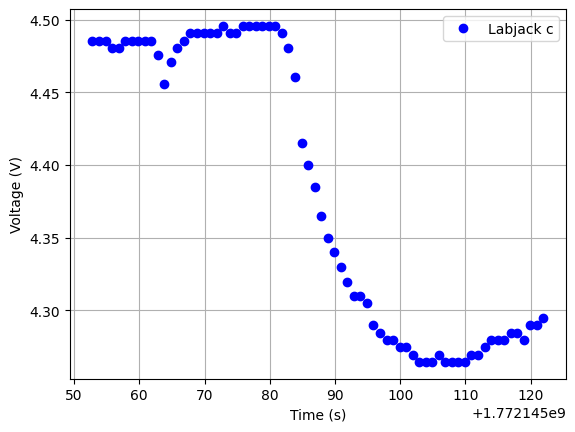

In [6]:
plt.plot(Time_c, jack_v_c, 'bo', label = 'Labjack c')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.savefig('V_T_Labjack_cold_26Feb2026.png')

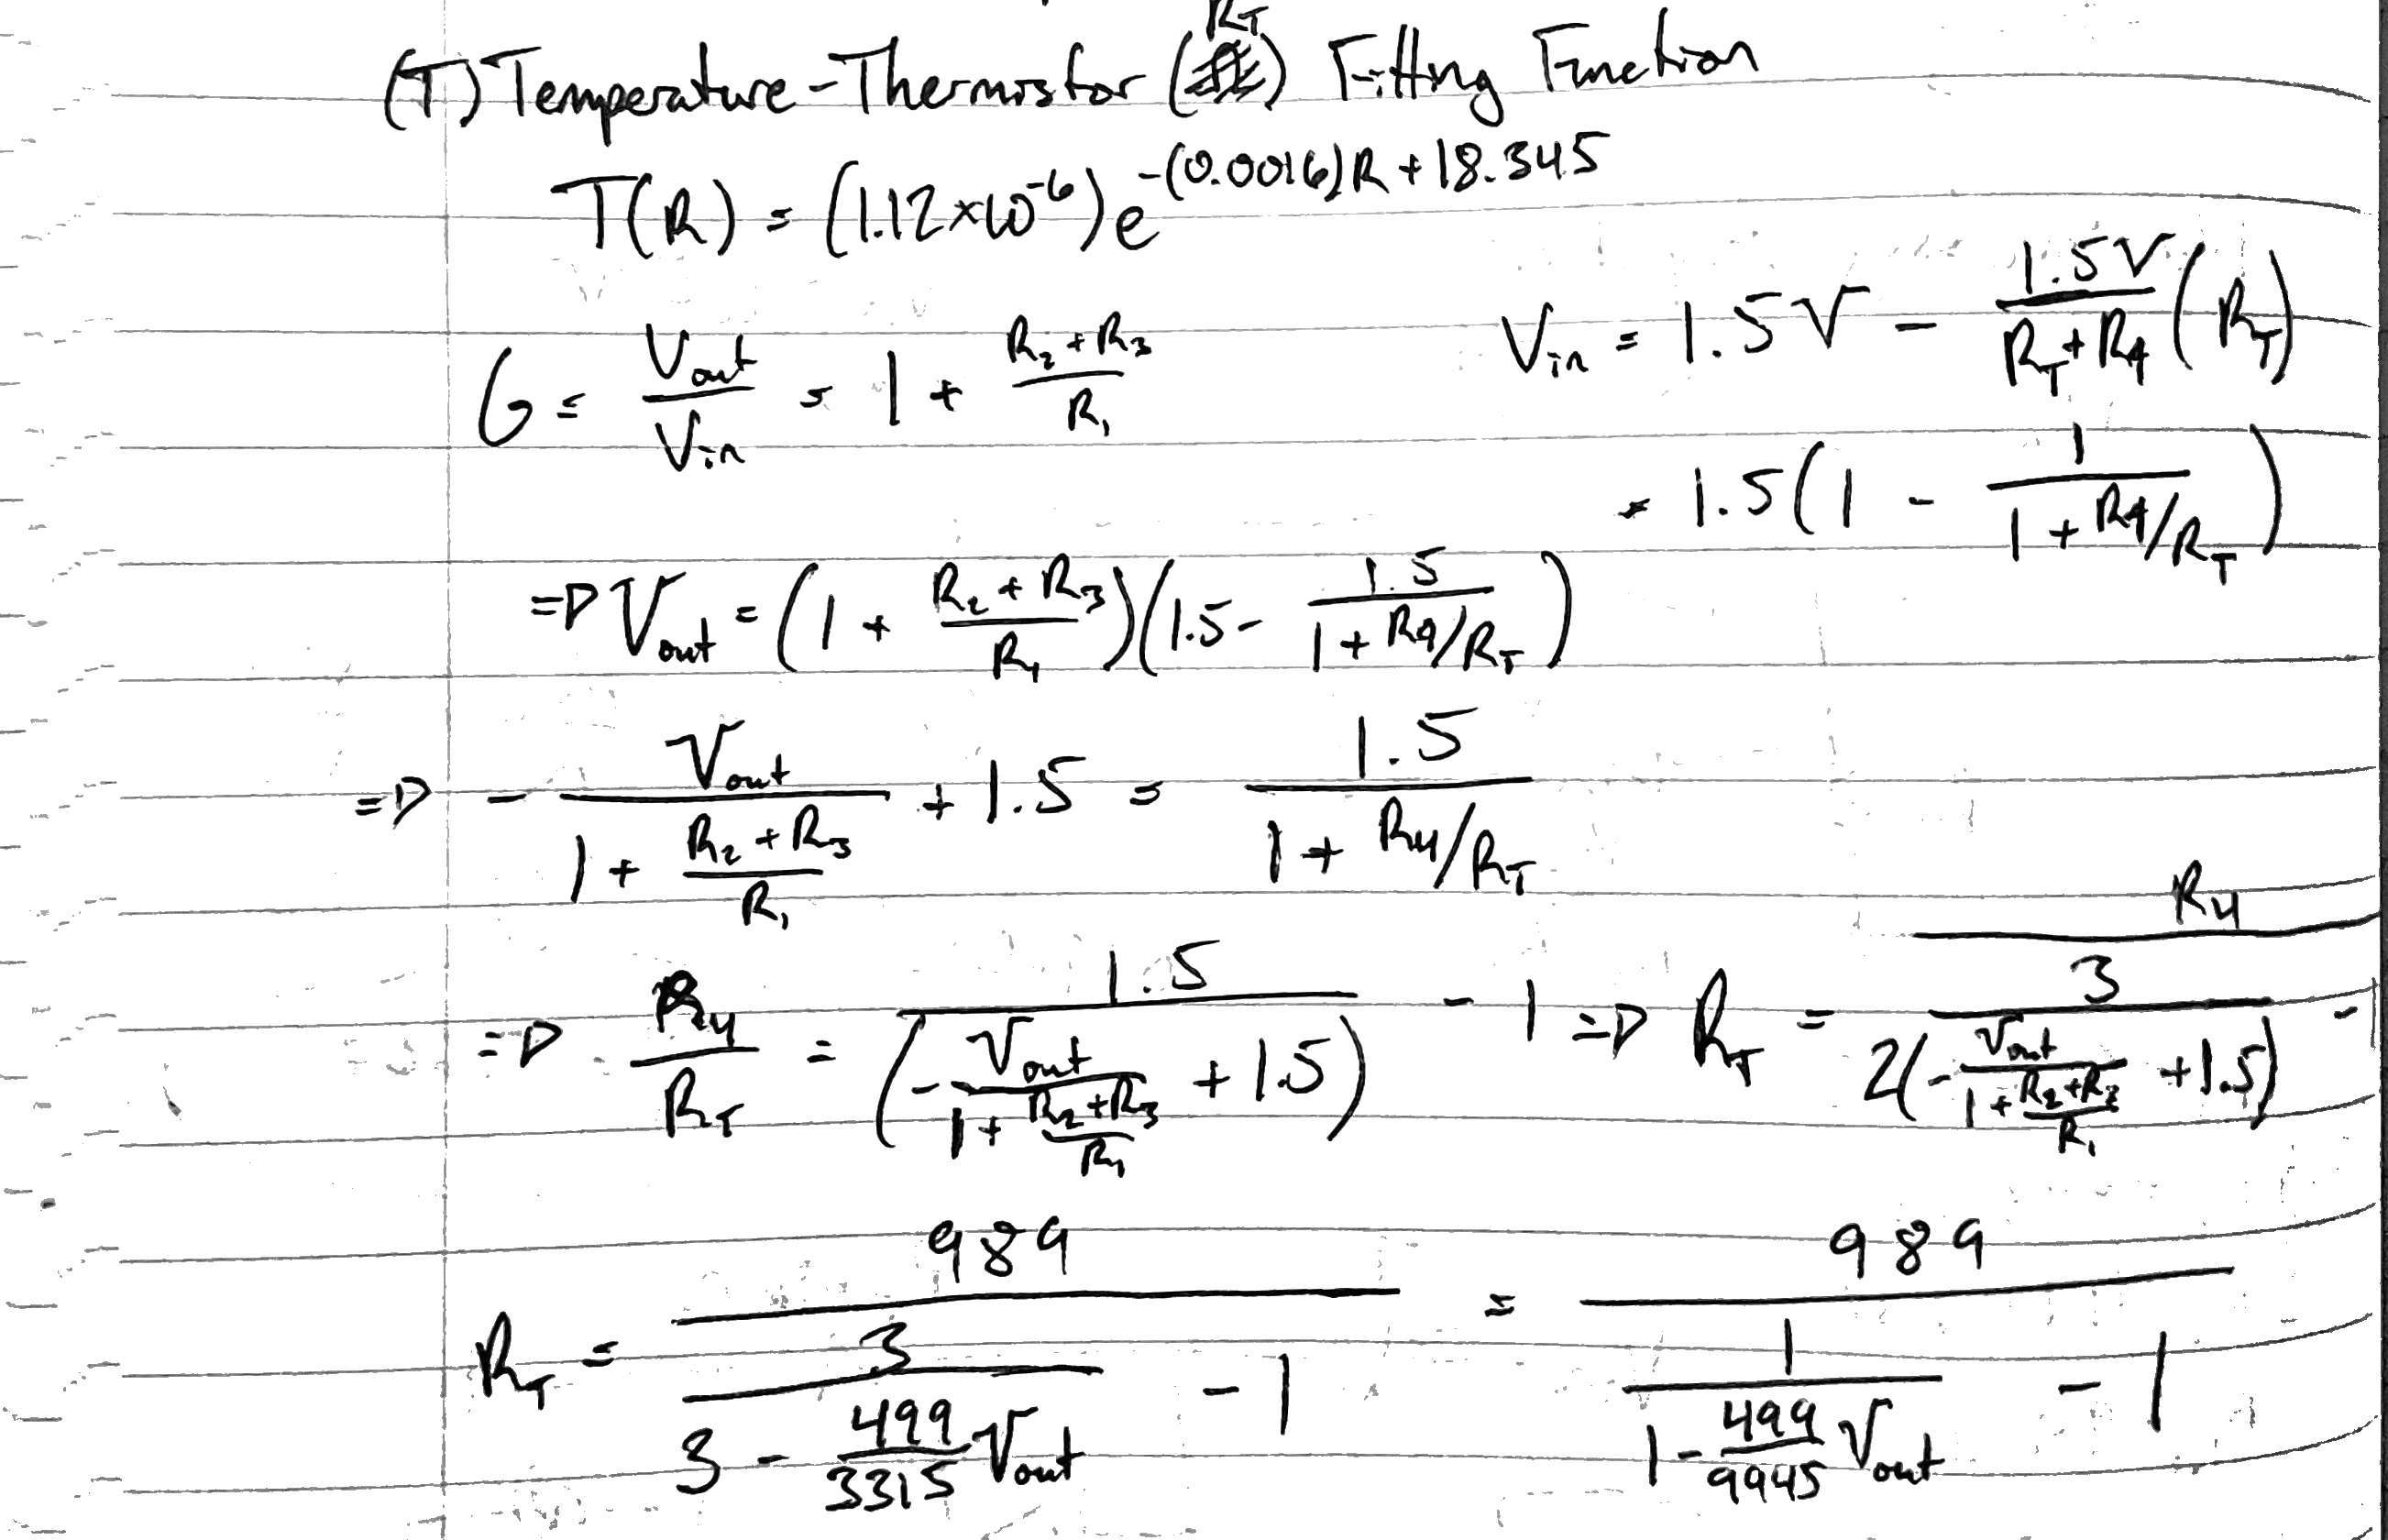

In [ ]:
#Converting measured voltage to the thermistor's Resistance
d = 989
e = 499/9945

R = d / ( ( 1 / (1 - e*jack_v) ) - 1 )

In [ ]:
#Converting thermistor's resistance to approximate temperature
a = 0.00000112
b = -0.0016
c = 18.345

T = a*np.exp(b*R + c)

In [ ]:
#Plotting estimated temperature over measured time
plt.plot(Time, T, 'bo', label = 'Thermistor Temperature Over Time Approx.')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()

# Do not disassemble your breadboard!!  You will be using this thermistor circuit in Lab 7.